In [1]:
#### Variables


In [2]:
#### Recap of functions

def adder(firstNumber, secondNumber):
    return firstNumber + secondNumber


def sayHello(name):
    print("Hello", name)



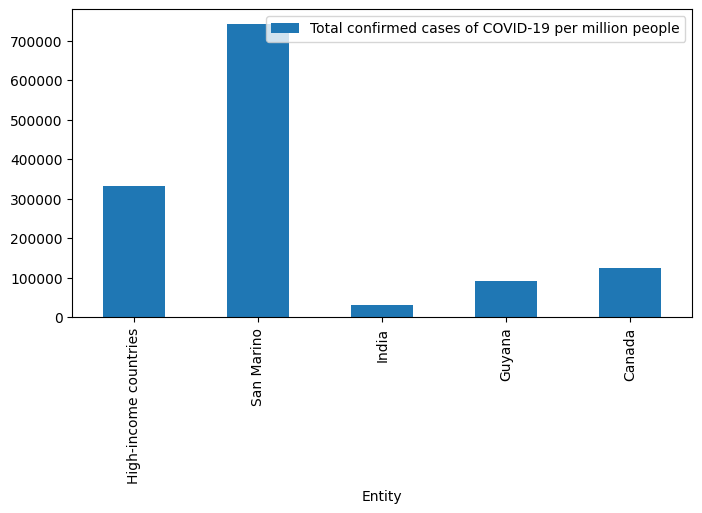

In [3]:
### Pandas

import pandas as pd 

data = pd.read_csv('full_data/cumulative-confirmed-covid-19-cases-per-million-people.csv')
# data = data.loc[data['Entity'] == 'Australia']

side = data.copy()

# data = data.loc[pd.to_datetime(data['Day'])]
data = data.loc[data['Day'] == data['Day'].max()]

# print(data)
# data.sort_values(by=['Total confirmed cases of COVID-19 per million people'], ascending=False, inplace=True)
# data = data[:10]
data = data.sample(n=5)


# data.plot(kind='bar', x='Entity', y='Total confirmed cases of COVID-19 per million people', figsize=(8, 4))

ax = data.plot(kind='bar', x='Entity', y='Total confirmed cases of COVID-19 per million people', figsize=(8, 4))

fig = ax.get_figure()
fig.savefig('examples/first.png', dpi=300, bbox_inches='tight')

/var/folders/p5/291tnlbj3vn89gqk4spr3v9h0000gn/T/ipykernel_36706/877154748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(


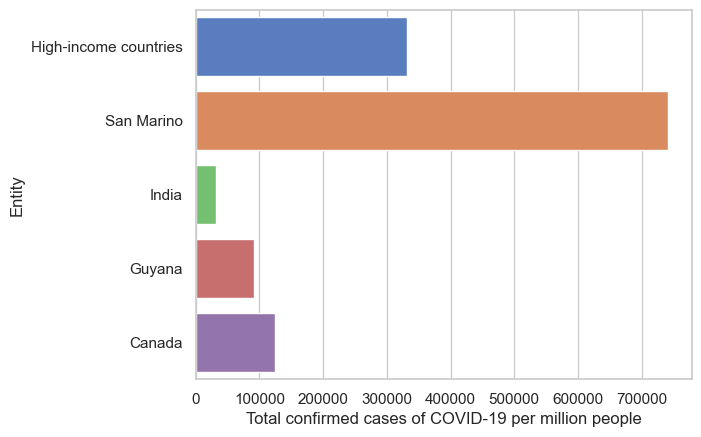

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style="whitegrid")

fig = sns.barplot(
    data=data, 
y='Entity', x='Total confirmed cases of COVID-19 per million people',
    palette="muted",

)

plt.savefig("examples/two.png", dpi=300, bbox_inches="tight")

# plt.xticks(rotation=45, ha='right')

In [6]:
# !pip3 install plotly
# !pip install --upgrade nbformat
!pip3 install --upgrade kaleido

pop = pd.read_csv('full_data/population-unwpp/population-unwpp.csv')
pop = pop.loc[pop['Year'] == pop['Year'].max()]
pop.drop(columns={'Code', 'Year'}, inplace=True)
# print(pop)
# print(pop.columns.tolist())

scat = pd.merge(side.sample(n=20), pop, on='Entity', how='left')
scat.drop(columns={'Code'}, inplace=True)
# print(scat)
# print(scat.columns.tolist())

import plotly.express as px

# px.bar(data,y='Entity', x='Total confirmed cases of COVID-19 per million people',)

fig = px.scatter(scat, y='Population (historical estimates)',hover_data=['Entity'],
                  x='Total confirmed cases of COVID-19 per million people')

# fig.show()

fig.write_image('examples/three.png', scale=3)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
